# Data Science Project: Planning Report
## Individual Assignment - DSCI 100

**Author:** Rongge Lu 33228065<br>
**Date:** November 14, 2025

This notebook contains the planning stage for predicting newsletter subscription among Minecraft server players.

In [1]:
library(tidyverse)
library(repr)

options(repr.plot.width=10, repr.plot.height=6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## 1. Data Description

### 1.1 Load the Dataset

In [2]:
players_df <- read_csv('players.csv')

head(players_df)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


### 1.2 Dataset Overview

In [3]:
cat("\n=== DATASET OVERVIEW ===\n")
cat(sprintf("Number of observations: %d\n", nrow(players_df)))
cat(sprintf("Number of variables: %d\n", ncol(players_df)))
cat(sprintf("\nVariable names: %s\n", paste(names(players_df), collapse=", ")))


=== DATASET OVERVIEW ===
Number of observations: 196
Number of variables: 7

Variable names: experience, subscribe, hashedEmail, played_hours, name, gender, Age


In [4]:
cat("\n=== DATA STRUCTURE ===\n")
glimpse(players_df)

cat("\n=== MISSING VALUES ===\n")
colSums(is.na(players_df))


=== DATA STRUCTURE ===
Rows: 196
Columns: 7
$ experience   <chr> "Pro", "Veteran", "Veteran", "Amateur", "Regular", "Amate…
$ subscribe    <lgl> TRUE, TRUE, FALSE, TRUE, TRUE, TRUE, TRUE, FALSE, TRUE, T…
$ hashedEmail  <chr> "f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8…
$ played_hours <dbl> 30.3, 3.8, 0.0, 0.7, 0.1, 0.0, 0.0, 0.0, 0.1, 0.0, 1.6, 0…
$ name         <chr> "Morgan", "Christian", "Blake", "Flora", "Kylie", "Adrian…
$ gender       <chr> "Male", "Male", "Male", "Female", "Male", "Female", "Fema…
$ Age          <dbl> 9, 17, 17, 21, 21, 17, 19, 21, 47, 22, 23, 17, 25, 22, 17…

=== MISSING VALUES ===


experience    subscribe  hashedEmail played_hours         name       gender 
           0            0            0            0            0            0 
         Age 
           2

### 1.3 Summary Statistics - Mean Values for Quantitative Variables

In [5]:
mean_played_hours <- mean(players_df$played_hours, na.rm = TRUE)
mean_age <- mean(players_df$Age, na.rm = TRUE)

cat(sprintf("Mean played_hours: %.2f hours\n", mean_played_hours))
cat(sprintf("Mean Age: %.2f years\n", mean_age))

summary_stats <- tibble(
    Variable = c('played_hours', 'Age'),
    Mean = c(mean_played_hours, mean_age)
)

print(summary_stats)

Mean played_hours: 5.85 hours
Mean Age: 21.14 years
# A tibble: 2 × 2
  Variable      Mean
  <chr>        <dbl>
1 played_hours  5.85
2 Age          21.1 


## 2. Research Questions

### 2.1 Broad Question

What player characteristics and behaviors are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

### 2.2 Specific Question

Can player experience level, hours played, age, and gender predict newsletter subscription status in the Minecraft server player dataset?

### 2.3 Relevance to Data

The dataset contains both the response variable (subscribe) and multiple explanatory variables (experience, played_hours, Age, gender) that can be used to build a predictive model. This will help the research team understand which player characteristics are associated with higher engagement (newsletter subscription), allowing them to better target recruitment and resource allocation.

## 3. Exploratory Data Analysis and Visualization

### 3.1 Experience Level Distribution


Insight: Amateur and Veteran players are most common, suggesting varied experience levels.


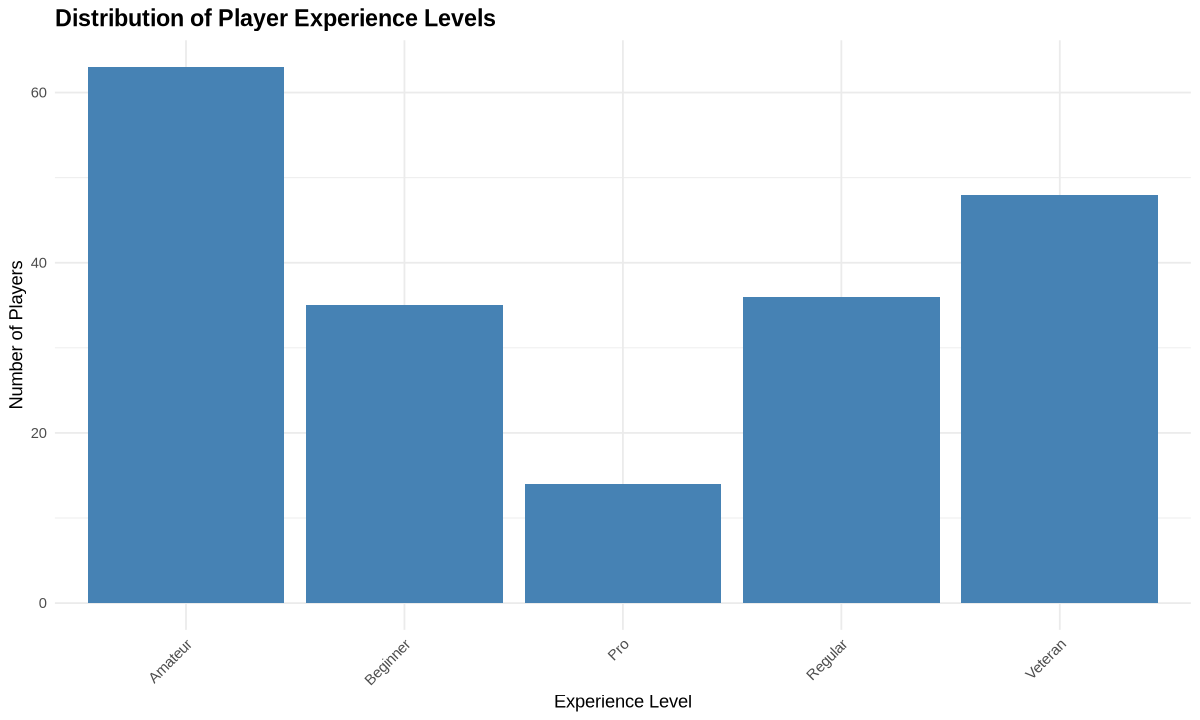

In [6]:
experience_plot <- players_df %>%
    count(experience) %>%
    ggplot(aes(x = experience, y = n)) +
    geom_bar(stat = "identity", fill = "steelblue") +
    labs(title = "Distribution of Player Experience Levels",
         x = "Experience Level",
         y = "Number of Players") +
    theme_minimal() +
    theme(plot.title = element_text(face = "bold", size = 14),
          axis.text.x = element_text(angle = 45, hjust = 1))

print(experience_plot)

cat("\nInsight: Amateur and Veteran players are most common, suggesting varied experience levels.\n")

### 3.2 Subscription Rate by Experience Level


Insight: Subscription rates vary by experience level, suggesting it could be a useful predictor.


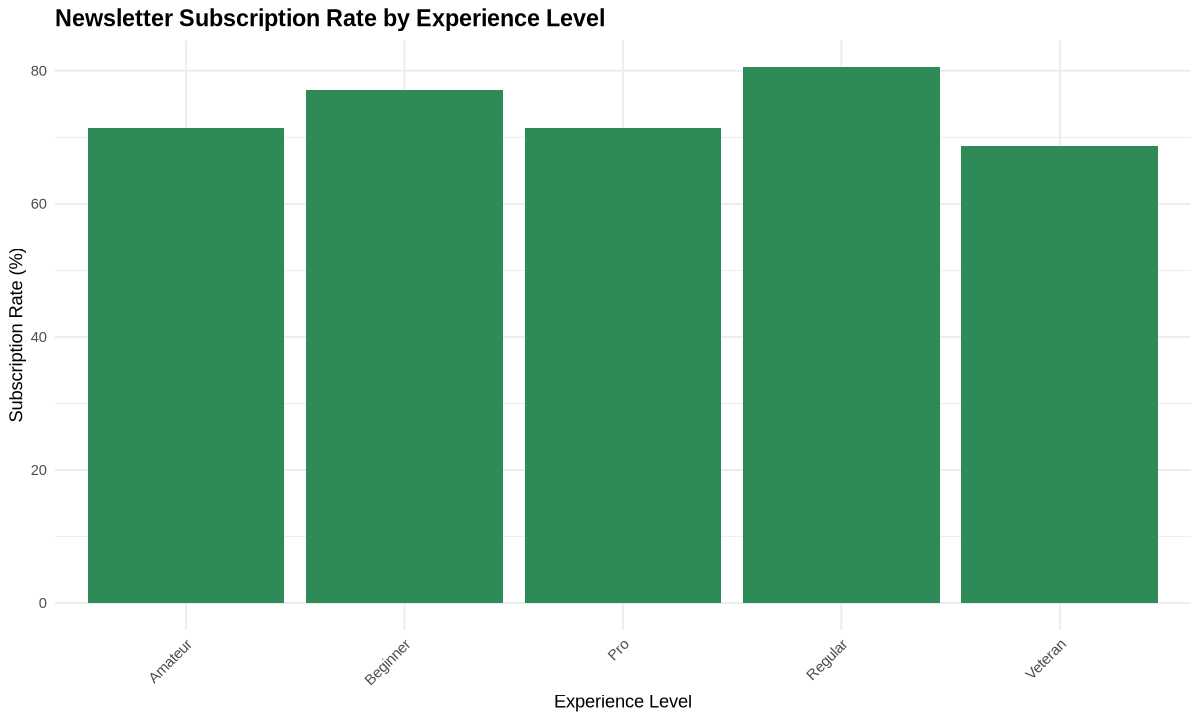

In [7]:
sub_by_exp <- players_df %>%
    group_by(experience) %>%
    summarize(
        subscribed = sum(subscribe == TRUE, na.rm = TRUE),
        total = n(),
        rate = (subscribed / total) * 100
    )

sub_plot <- ggplot(sub_by_exp, aes(x = experience, y = rate)) +
    geom_bar(stat = "identity", fill = "seagreen") +
    labs(title = "Newsletter Subscription Rate by Experience Level",
         x = "Experience Level",
         y = "Subscription Rate (%)") +
    theme_minimal() +
    theme(plot.title = element_text(face = "bold", size = 14),
          axis.text.x = element_text(angle = 45, hjust = 1))

print(sub_plot)

cat("\nInsight: Subscription rates vary by experience level, suggesting it could be a useful predictor.\n")

### 3.3 Distribution of Played Hours


Insight: Played hours is highly right-skewed.


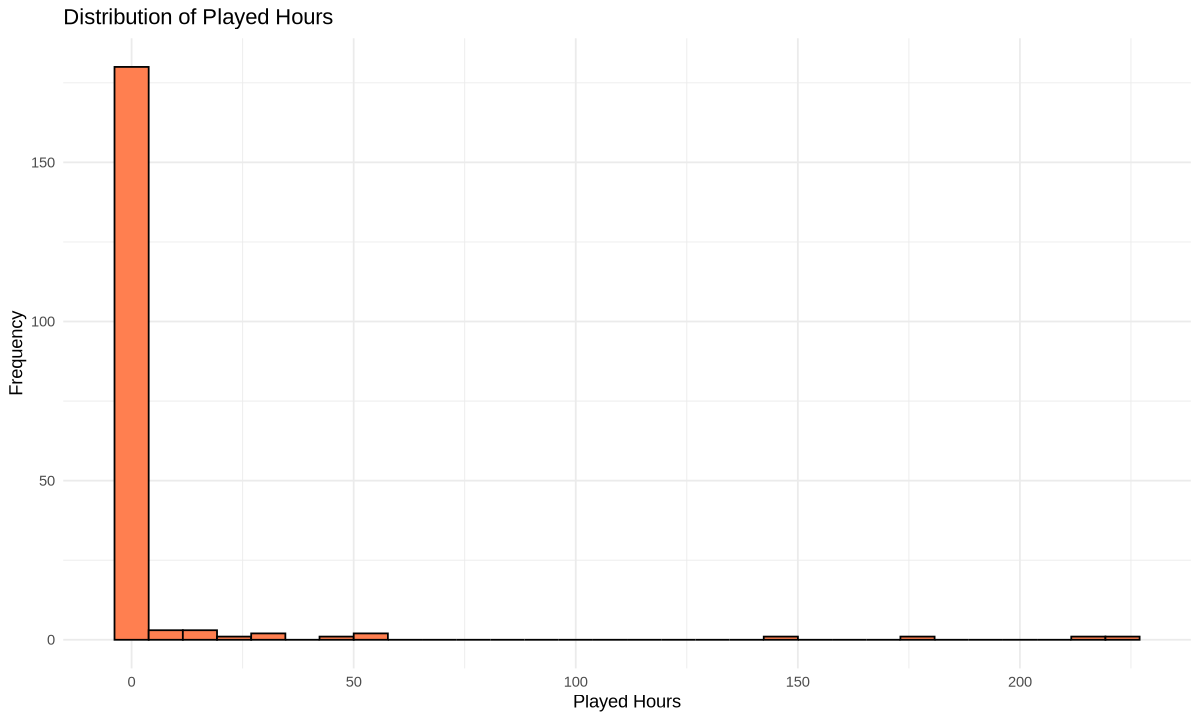

In [8]:
hours_hist <- ggplot(players_df, aes(x = played_hours)) +
    geom_histogram(bins = 30, fill = "coral", color = "black") +
    labs(title = "Distribution of Played Hours",
         x = "Played Hours",
         y = "Frequency") +
    theme_minimal()

print(hours_hist)

cat("\nInsight: Played hours is highly right-skewed.\n")

## 4. Methods and Plan

### Proposed Method: Logistic Regression

#### 4.1 Why is this method appropriate?
- Our response variable (subscribe) is binary (yes/no), making logistic regression the right choice
- We want to predict probabilities of subscription, which logistic regression does well
- It's simple to interpret and understand the relationship between player characteristics and subscription
- Works well with mixed data types (categorical and numerical variables)

#### 4.2 Which assumptions are required to apply this method?
- Independence: Each player's subscription decision is independent of others
- No extreme outliers that could skew results (we'll check this during EDA)
- Large enough sample size (we have sufficient observations)
- Linear relationship between log-odds and predictors (we'll verify this)

#### 4.3 What are the potential limitations or weaknesses?
- Assumes linear relationships, which might not capture complex patterns
- Can be sensitive to outliers in the data
- May not perform well if predictors are highly correlated with each other
- Simple model might miss interactions between variables

#### 4.4 How are you going to compare and select the model?
- Use cross-validation to test model stability
- Compare accuracy, precision, and recall metrics
- Examine confusion matrix to see prediction errors
- Check if the model performs better than just guessing the most common class

#### 4.5 How are you going to process the data to apply the model?
- **Data splitting:** 80% training, 20% testing split
- **When to split:** After data cleaning but before any modeling
- **Validation approach:** 5-fold cross-validation on training data (no separate validation set)
- **Data preprocessing:** 
  - Convert categorical variables (experience, gender) to dummy variables
  - Apply log transformation to played_hours to fix skewness
  - Standardize numerical variables to same scale
- **Random seed:** Set to 123 for reproducible results
